# Finite Differences for the solution of Boundary Value Problems


In [5]:
# importing libraries
import numpy as np
import pandas as pd
import math
from matplotlib import pyplot as plt
from ipywidgets import interactive, fixed

We'll solve the following BVP using the linear shooting Method:

$$y'' = p(x)y' + q(x)y + r(x), \quad y(a) = \alpha,\quad y(b) = \beta.$$

Using the finite difference method.

# Definition of the BVP

In [4]:
# Define the IVP:

# Diff. Eqn.: y'' = p(x)y' + q(x)y +r(x)
# Define the ODE functions based on: y'' + p(x)y' + q(x)y = r(x)
def p(x): return 0
def q(x): return 2 + 4*x**2
def r(x): return 0

# Crout factorization and solve for tridiagonal linear systems

In [6]:
# Crout Factorization
# input: tridiagonal entries of A:
#        dsub: lower diagonal
#           d: main diagonal
#        dsup: uppper diagonal
# output: Crout LU factorization

def crout(dsub, d, dsup):
    n = len(d)

    # dsub: lower diagonal (indices 0 to n-2)
    # d:    main diagonal  (indices 0 to n-1)
    # dsup: upper diagonal (indices 0 to n-2)

    for i in range(1, n):
        # Calculate the U element for the previous row
        # U[i-1, i] = A[i-1, i] / L[i-1, i-1]
        dsup[i-1] = dsup[i-1] / d[i-1]

        # Calculate the L element for the current diagonal
        # L[i, i] = A[i, i] - L[i, i-1] * U[i-1, i]
        d[i] = d[i] - dsub[i-1] * dsup[i-1]

    return dsub, d, dsup

# Forward and Backward sub for tridiagonal systems
# input: tridiagonal entries of A:
#        dsub: lower diagonal
#           d: main diagonal
#        dsup: uppper diagonal
#         rhs: right-hand-side of system
# output: Crout LU factorization
def fbsub(dsub, d, dsup, rhs):
    n = len(d)
    z = np.zeros(n)  # This is the 'y' from our hand math (intermediate)
    v = np.zeros(n)  # This is the 'x' from our hand math (final solution)

    ###############################################################
    # Forward sub (Solving Lz = rhs):
    # The first element is simple: z0 = b0 / l00
    z[0] = rhs[0] / d[0]

    for i in range(1, n):
        # z[i] = (rhs[i] - l_{i, i-1} * z[i-1]) / l_{ii}
        # In our code: l_{i, i-1} is dsub[i-1] and l_{ii} is d[i]
        z[i] = (rhs[i] - dsub[i-1] * z[i-1]) / d[i]

    ###############################################################
    # Backward sub (Solving Uv = z):
    # The last element is simple: v_n = z_n (since U diagonal is all 1s)
    v[n-1] = z[n-1]

    for i in range(1, n):
        # Working backwards from the second-to-last element
        idx = n - i - 1
        # v[idx] = z[idx] - u_{idx, idx+1} * v[idx+1]
        # In our code: u_{idx, idx+1} is dsup[idx]
        v[idx] = z[idx] - dsup[idx] * v[idx+1]

    return v

# Boundary Value Problems (BVP)
## The Finite Difference Method

In [7]:
# Approximate solution to BVP using Finite Difference method
# for 2nd-order ODE where 2nd-order central differences
# used for y' and y''

def fdiff(a, b, alpha, beta, n):
    x    = np.zeros(n+2)
    w    = np.zeros(n+2)
    d    = np.zeros(n)
    dsub = np.zeros(n-1)
    dsup = np.zeros(n-1)
    y    = np.zeros(n)

    h    = (b-a)/(n+1)
    x    = a + h*np.array(range(0, n+2))

    ###############################################################
    # Define entries of nxn matrix A

    # Row 1 of A (i=0 in code, corresponds to x_1)
    d[0]    = -2 + h**2 * q(x[1])
    dsup[0] = 1 + (h/2) * p(x[1])
    # RHS includes the boundary condition alpha: -(1 - h/2 * p(x1)) * alpha
    y[0]    = h**2 * r(x[1]) - (1 - (h/2) * p(x[1])) * alpha

    # Rows 2 to n-1 of A
    for i in range(1, n-1):
        # Index i corresponds to grid point x[i+1]
        dsub[i-1] = 1 - (h/2) * p(x[i+1])
        d[i]      = -2 + h**2 * q(x[i+1])
        dsup[i]   = 1 + (h/2) * p(x[i+1])
        y[i]      = h**2 * r(x[i+1])

    # Row n (i=n-1 in code, corresponds to x_n)
    dsub[n-2] = 1 - (h/2) * p(x[n])
    d[n-1]    = -2 + h**2 * q(x[n])
    # RHS includes the boundary condition beta: -(1 + h/2 * p(xn)) * beta
    y[n-1]    = h**2 * r(x[n]) - (1 + (h/2) * p(x[n])) * beta

    ###############################################################
    # Solve using Crout Factorization Method
    crout(dsub, d, dsup)

    # Perform solve using sequential forward & backward sub
    w[1:n+1] = fbsub(dsub, d, dsup, y)

    # Boundary conditions
    w[0]   = alpha
    w[n+1] = beta

    return x, w


      x      w[i]      y(x)
0   0.0  1.000000  1.000000
1   0.1  1.105221  1.010050
2   0.2  1.221495  1.040811
3   0.3  1.349983  1.094174
4   0.4  1.491972  1.173511
5   0.5  1.648880  1.284025
6   0.6  1.822277  1.433329
7   0.7  2.013896  1.632316
8   0.8  2.225655  1.896481
9   0.9  2.459670  2.247908
10  1.0  2.718282  2.718282


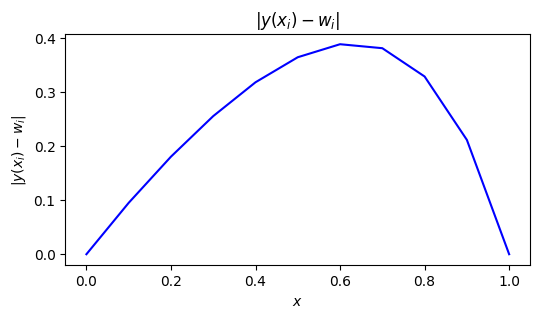

In [11]:
import numpy as np


# Parameters
a, b = 0, 1
alpha, beta = 1, np.exp(1)
n_values = [10, 100, 1000]

# Run your solver
[x, w] = fdiff(a, b, alpha, beta, n)

# Exact solution for comparison
yexact = np.exp(x**2)


plt.figure(figsize=(6, 3))
plt.plot(x,np.abs(yexact-w),'-',color='blue')
plt.xlabel(f'$x$')
plt.ylabel(f'$|y(x_i) - w_i|$')
plt.title(f'$|y(x_i) - w_i|$');

data = [x, w, yexact]
data = np.transpose(data)
print(pd.DataFrame(data, columns=["x", "w[i]","y(x)"]))